In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def rmse(X, Y):
    return np.sqrt(np.mean((X - Y) ** 2))
def rel_rmse(X, Y):
    return rmse(X, Y) / rmse(Y, 0)

In [2]:
def derive_compact(field, direction, dy):
    rhs = np.zeros_like(field)
    rhs = np.roll(field, -1, axis=direction) - np.roll(field, 1, axis=direction)
    rhs *= 3.0 / dy
    length = field.shape[direction]
    ab = np.zeros((3, length))
    ab[0, 2:] = 1
    ab[1, :] = 4
    ab[2, :-2] = 1
    # BC
    ab[0, 1] = 0
    ab[2, -2] = 0
    rhs_reordered = np.moveaxis(rhs, direction, 0)
    reordered_shape = rhs_reordered.shape
    rhs_reshaped = rhs_reordered.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), ab, rhs_reshaped)
    field_prime = np.moveaxis(field_prime_reshaped.reshape(reordered_shape), 0, direction)
    return field_prime

In [3]:
resolution = 100
domain_lim = 50 * np.pi
x = np.linspace(0, domain_lim, resolution)

In [4]:
y = np.cos(x)

In [5]:
y.shape

(100,)

In [6]:
y_prime = derive_compact(y, 0, domain_lim / (resolution - 1))

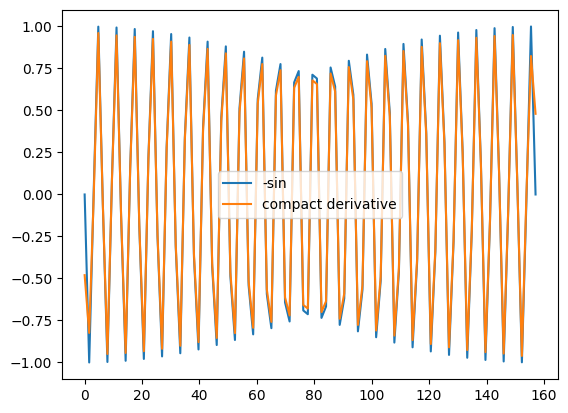

In [7]:
plt.plot(x, -np.sin(x), label="-sin")
plt.plot(x, y_prime, label="compact derivative")
plt.legend()
plt.show()

In [8]:
rel_rmse(-np.sin(x), y_prime)

np.float64(0.11834064404574214)

In [9]:
def derive_compact_bc(field, direction, dy):
    shape = field.shape
    field_reordered = np.moveaxis(field, direction, 0)
    rhs = np.zeros_like(field_reordered)
    rhs[1:-1] = field_reordered[2:] - field_reordered[0:-2]
    rhs[0, ...] = 0
    rhs[-1, ...] = 0
    rhs *= 3.0 / dy
    length = field.shape[direction]
    ab = np.zeros((3, length))
    ab[0, 2:] = 1
    ab[1, :] = 4
    ab[2, :-2] = 1
    # BC
    ab[0, 1] = 0
    ab[2, -2] = 0
    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), ab, rhs_reshaped)
    field_prime = np.moveaxis(field_prime_reshaped.reshape(shape), 0, direction)
    return field_prime

In [10]:
y_prime_bc = derive_compact_bc(y, 0, domain_lim / (resolution - 1))

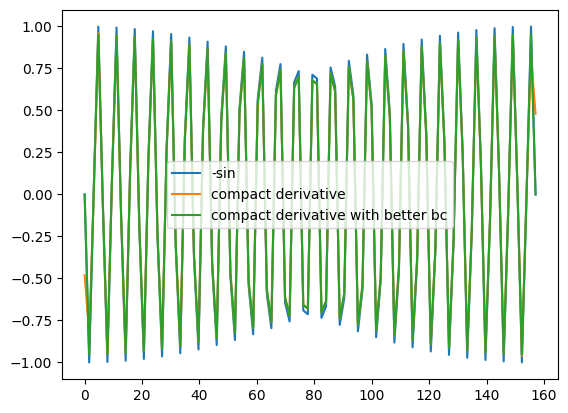

In [11]:
plt.plot(x, -np.sin(x), label="-sin")
plt.plot(x, y_prime, label="compact derivative")
plt.plot(x, y_prime_bc, label="compact derivative with better bc")
plt.legend()
plt.show()

In [12]:
rel_rmse(-np.sin(x), y_prime_bc)

np.float64(0.049516096910206975)